<a href="https://colab.research.google.com/github/pattichis/MLSP2026/blob/main/Adversarial_Examples_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adversarial Examples: A Fast Tutorial

This notebook attacks a pretrained ImageNet classifier (ResNet-18) with two standard attacks:

- **FGSM** (Fast Gradient Sign Method): a single gradient step.
- **PGD** (Projected Gradient Descent): many small steps, each projected back into an ε-ball.

It runs in about 15 minutes. A GPU runtime is faster (**Runtime → Change runtime type → GPU**), but CPU also works.

| Concept | Meaning |
|---|---|
| ε (epsilon) | The largest change allowed per pixel (an L∞ budget) |
| FGSM | One step: `x + ε·sign(∇ₓ loss)`. Fast but weak |
| PGD | Many small steps, each projected back into the ε-ball. The standard strong attack |
| Adversarial training | Train on PGD examples. Improves robustness but lowers clean accuracy |

## 1. Setup: model and one image

In [ ]:
import torch, torch.nn as nn, urllib.request
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
weights = ResNet18_Weights.DEFAULT
labels = weights.meta["categories"]

# Normalize inside the model so attacks work in pixel space [0,1]
class Normalized(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
        self.register_buffer("mean", torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    def forward(self, x):
        return self.m((x - self.mean) / self.std)

model = Normalized(resnet18(weights=weights)).eval().to(device)

urllib.request.urlretrieve("https://github.com/pytorch/hub/raw/master/images/dog.jpg", "dog.jpg")
prep = T.Compose([T.Resize(256), T.CenterCrop(224), T.ToTensor()])
x = prep(Image.open("dog.jpg").convert("RGB")).unsqueeze(0).to(device)

def predict(img):
    with torch.no_grad():
        p = model(img).softmax(1)
    c = p.argmax(1).item()
    return f"{labels[c]} ({p[0, c]:.0%})"

with torch.no_grad():
    y = model(x).argmax(1)          # use the clean prediction as the label
print("Device:", device)
print("Clean:", predict(x))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 127MB/s]


Device: cuda
Clean: Samoyed (88%)


## 2. FGSM: a single gradient step

Take the gradient of the loss with respect to the **input**, not the weights. Then move every pixel by ±ε in whichever direction increases the loss.

In [ ]:
loss_fn = nn.CrossEntropyLoss()

def fgsm(x, y, eps):
    x = x.clone().requires_grad_(True)
    loss_fn(model(x), y).backward()
    return (x + eps * x.grad.sign()).clamp(0, 1).detach()

## 3. PGD: repeated FGSM steps, projected back into the ε-ball

PGD starts from a random point near the image, takes several small signed-gradient steps, and after each step clips the perturbation back to at most ε per pixel.

In [ ]:
def pgd(x, y, eps, alpha=None, steps=10):
    alpha = alpha or eps / 4
    x_adv = (x + torch.empty_like(x).uniform_(-eps, eps)).clamp(0, 1)   # random start
    for _ in range(steps):
        x_adv.requires_grad_(True)
        grad, = torch.autograd.grad(loss_fn(model(x_adv), y), x_adv)
        x_adv = x_adv.detach() + alpha * grad.sign()
        x_adv = (x + (x_adv - x).clamp(-eps, eps)).clamp(0, 1)          # project
    return x_adv.detach()

## 4. Run and visualize

The clean and attacked images should look identical, but the predicted labels should differ. PGD usually succeeds even when FGSM doesn't.

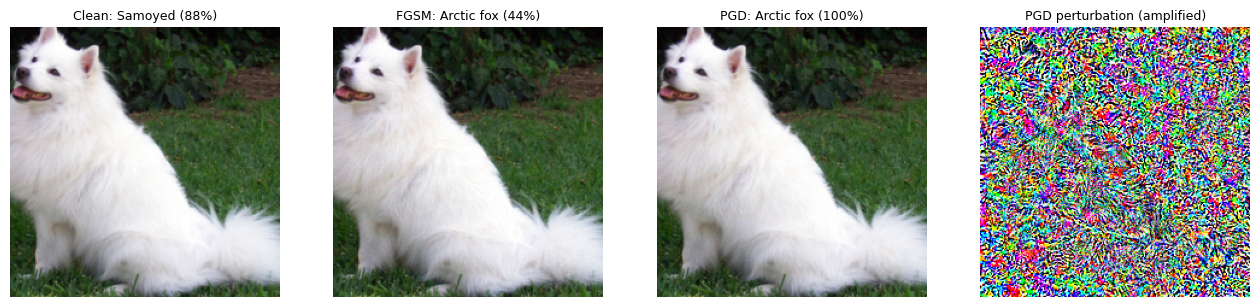

In [ ]:
eps = 2 / 255                      # changes each pixel by less than 1%
x_f, x_p = fgsm(x, y, eps), pgd(x, y, eps)
noise = ((x_p - x) / (2 * eps) + 0.5).clamp(0, 1)   # rescale the perturbation so it's visible

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
panels = [(x, "Clean: " + predict(x)),
          (x_f, "FGSM: " + predict(x_f)),
          (x_p, "PGD: " + predict(x_p)),
          (noise, "PGD perturbation (amplified)")]
for a, (img, title) in zip(ax, panels):
    a.imshow(img[0].permute(1, 2, 0).cpu())
    a.set_title(title, fontsize=9)
    a.axis("off")
plt.show()

## 5. Experiment: how large does ε need to be?

In [ ]:
for e in [0.5, 1, 2, 4, 8]:
    print(f"eps={e}/255  FGSM: {predict(fgsm(x, y, e/255)):28s} PGD: {predict(pgd(x, y, e/255))}")

eps=0.5/255  FGSM: Arctic fox (51%)             PGD: Arctic fox (69%)
eps=1/255  FGSM: Arctic fox (51%)             PGD: Arctic fox (99%)
eps=2/255  FGSM: Arctic fox (44%)             PGD: Arctic fox (100%)
eps=4/255  FGSM: Arctic fox (31%)             PGD: white wolf (100%)
eps=8/255  FGSM: Arctic fox (31%)             PGD: white wolf (95%)


## 6. Targeted attack: force a specific class

Instead of pushing away from the true class, pull toward a chosen target by *minimizing* the loss for that class (note the minus sign).

In [ ]:
def pgd_targeted(x, target, eps, alpha=None, steps=40):
    alpha = alpha or eps / 8
    x_adv = x.clone()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        grad, = torch.autograd.grad(loss_fn(model(x_adv), target), x_adv)
        x_adv = x_adv.detach() - alpha * grad.sign()                    # minus: move toward target
        x_adv = (x + (x_adv - x).clamp(-eps, eps)).clamp(0, 1)
    return x_adv.detach()

target = torch.tensor([1], device=device)       # ImageNet class 1 = goldfish
x_t = pgd_targeted(x, target, eps=4/255)
print("Target:", labels[target.item()])
print("Result:", predict(x_t))

Target: goldfish
Result: goldfish (100%)


## 7. Adversarial training (the main defense)

Adversarial training (Madry et al., 2017) is simple: in every training step, first attack the current batch with PGD, then update the model on the **attacked** images instead of the clean ones. The model learns to classify correctly anywhere inside the ε-ball.

We train two identical small CNNs on MNIST, one normally and one adversarially, and then attack both. This takes about 1 minute on a GPU and several minutes on CPU.

### 7a. Data, model, and a PGD attack that takes any network

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

torch.manual_seed(0)
train_ds = datasets.MNIST("data", train=True,  download=True, transform=T.ToTensor())
test_ds  = datasets.MNIST("data", train=False, download=True, transform=T.ToTensor())
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=500)

def make_cnn():
    return nn.Sequential(
        nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        nn.Flatten(), nn.Linear(64 * 7 * 7, 128), nn.ReLU(), nn.Linear(128, 10),
    ).to(device)

# Same PGD as section 3, but the network is an argument
def pgd_on(net, x, y, eps, steps=10):
    alpha = eps / 4
    x_adv = (x + torch.empty_like(x).uniform_(-eps, eps)).clamp(0, 1)
    for _ in range(steps):
        x_adv.requires_grad_(True)
        grad, = torch.autograd.grad(loss_fn(net(x_adv), y), x_adv)
        x_adv = x_adv.detach() + alpha * grad.sign()
        x_adv = (x + (x_adv - x).clamp(-eps, eps)).clamp(0, 1)
    return x_adv.detach()

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.42MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 126kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.82MB/s]


### 7b. Training: the only difference is one line

In [ ]:
EPS = 0.1   # MNIST pixels are in [0,1]; 0.1 is a moderate budget

def train(net, adversarial, epochs=1):
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    for _ in range(epochs):
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            if adversarial:
                net.eval()
                xb = pgd_on(net, xb, yb, EPS, steps=7)   # <-- attack the batch first
                net.train()
            loss = loss_fn(net(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    return net.eval()

def accuracy(net, eps=None):
    correct = 0
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        if eps:
            xb = pgd_on(net, xb, yb, eps, steps=20)       # stronger attack at test time
        with torch.no_grad():
            correct += (net(xb).argmax(1) == yb).sum().item()
    return correct / len(test_ds)

standard = train(make_cnn(), adversarial=False)
robust   = train(make_cnn(), adversarial=True)

### 7c. Compare: clean accuracy vs. accuracy under PGD attack

Both models are about equally accurate on clean images. Under attack, the standard model's accuracy drops sharply, while the adversarially trained model keeps most of its accuracy.

                         clean   PGD eps=0.1   PGD eps=0.2
Standard training        98.2%         69.3%          0.4%
Adversarial training     97.9%         92.3%         50.0%


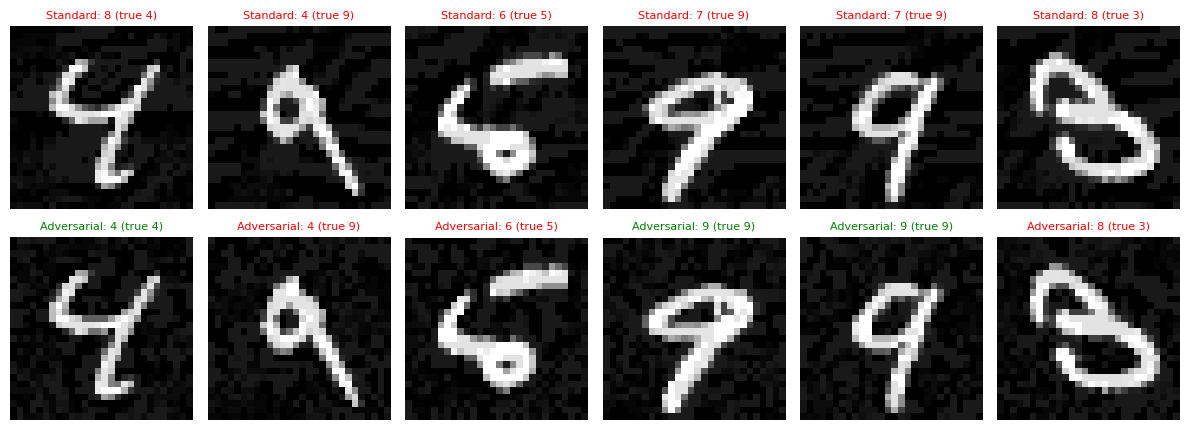

In [ ]:
print(f"{'':22s}{'clean':>8s}{'PGD eps=0.1':>14s}{'PGD eps=0.2':>14s}")
for name, net in [("Standard training", standard), ("Adversarial training", robust)]:
    print(f"{name:22s}{accuracy(net):8.1%}{accuracy(net, 0.1):14.1%}{accuracy(net, 0.2):14.1%}")

# Show digits that fool the standard model, and what the robust model says about its own attack
xb, yb = next(iter(test_loader))
xb, yb = xb.to(device), yb.to(device)
x_std = pgd_on(standard, xb, yb, EPS, steps=20)    # the attack needs gradients, so not inside no_grad
with torch.no_grad():
    fooled = standard(x_std).argmax(1) != yb
xb, yb = xb[fooled][:6], yb[fooled][:6]
fig, ax = plt.subplots(2, 6, figsize=(12, 4.5))
for row, (name, net) in enumerate([("Standard", standard), ("Adversarial", robust)]):
    x_adv = pgd_on(net, xb, yb, EPS, steps=20)
    with torch.no_grad():
        pred = net(x_adv).argmax(1)
    for i in range(6):
        ax[row, i].imshow(x_adv[i, 0].cpu(), cmap="gray")
        ax[row, i].set_title(f"{name}: {pred[i].item()} (true {yb[i].item()})", fontsize=8,
                             color="green" if pred[i] == yb[i] else "red")
        ax[row, i].axis("off")
plt.tight_layout(); plt.show()

Try: increase `EPS` to 0.2 or 0.3 (retrain both models), or train for more epochs. Larger ε makes the robust model more robust but usually costs some clean accuracy, which is the classic robustness–accuracy trade-off.

## Next steps

- Kolter & Madry, *Adversarial Robustness: Theory and Practice* (adversarial-ml-tutorial.org), chapters 1–4.
- Goodfellow et al., 2014, *Explaining and Harnessing Adversarial Examples* (FGSM).
- Madry et al., 2017, *Towards Deep Learning Models Resistant to Adversarial Attacks* (PGD).
- Libraries: `torchattacks`, IBM Adversarial Robustness Toolbox, RobustBench.